## **COSMOLOGICAL CONSTRAINTS ON THE BARYON FRACTION IN THE IGM FROM FRB DATA WITH wCDM COSMOLOGY**

The goal is to constrain the baryon fraction in the IGM with wCDM cosmology using FRB dispersion measures. The dark energy equation of state is a free constant parameter $w \neq -1$.

## **1. DATA PROCESSING**

The observed dispersion measure of a FRB is given by
$$
DM_{\rm obs}(z) = DM_{\rm MW} + DM_{\rm IGM}(z) + DM_{\rm host}(z),
$$
where the Milky Way contribution is
$$
DM_{\rm MW} = DM_{\rm MW,ISM} + DM_{\rm MW,halo}.
$$

Following the paper, we assume a constant Milky Way halo contribution
$$
DM_{\rm MW,halo} = 50\;{\rm pc\,cm^{-3}}.
$$

The observed **extragalactic** dispersion measure is defined as
$$
DM_{\rm ext}(z) \equiv DM_{\rm obs}(z) - DM_{\rm MW}.
$$

**16 localised FRBs** whose dispersion measures trace the electron column density along the line of sight.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Load FRB data
# ---------------------------------------------------------------------------
url = "https://drive.google.com/uc?id=1icokvCOoPPHrQiLjxlAUyo_TXktPXAKb&export=download"
df  = pd.read_csv(url)
df.head()

,Name,z,DM_MW_ISM,DM_obs,sigma_obs
0,FRB180916B,0.03370,200.0,348.80,0.2
1,FRB201124A,0.09800,123.2,413.52,0.5
2,FRB190608B,0.11780,37.2,338.70,0.5
3,FRB200430A,0.16000,27.0,380.25,0.4
4,FRB121102A,0.19273,188.0,557.00,2.0


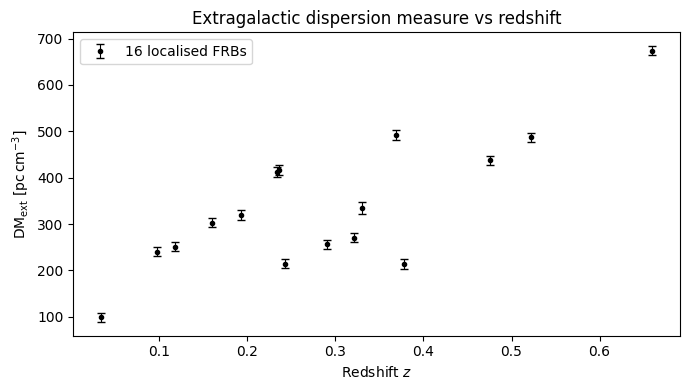

In [2]:
# ---------------------------------------------------------------------------
# 2. Derived quantities
# ---------------------------------------------------------------------------
DM_MW_HALO = 50.0
SIGMA_MW   = 10.0

df["DM_MW_halo"] = DM_MW_HALO
df["DM_MW"]      = df["DM_MW_ISM"] + DM_MW_HALO
df["DM_ext"]     = df["DM_obs"]    - df["DM_MW"]
df["sigma_MW"]   = SIGMA_MW
df["DM_ext_err"] = np.sqrt(df["sigma_obs"]**2 + SIGMA_MW**2)

DM_ext     = df["DM_ext"].values
z_frb      = df["z"].values
DM_ext_err = df["DM_ext_err"].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(z_frb, DM_ext, yerr=DM_ext_err,
            fmt='.k', capsize=3, elinewidth=0.8, label="16 localised FRBs")
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mathrm{DM}_{\rm ext}\ [\mathrm{pc\,cm^{-3}}]$")
ax.legend()
ax.set_title("Extragalactic dispersion measure vs redshift")
plt.tight_layout()
plt.show()

## **2. MODEL**

The theoretical extragalactic DM is the sum of the IGM and host galaxy contributions:
$$
\mathrm{DM}_{\rm ext}^{\rm th}(z) = \mathrm{DM}_{\rm IGM}(z) + \mathrm{DM}_{\rm host}(z).
$$

The host DM is redshifted into the observer frame:
$$
\mathrm{DM}_{\rm host}(z) = \frac{\mathrm{DM}_{\rm host,0}}{1+z}.
$$

In [3]:
def DM_host(z, DM_host_0):
    return DM_host_0 / (1 + z)

The IGM DM for a single FRB at redshift $z$ is (Lemos et al. Eq. 5):
$$
\mathrm{DM}_{\rm IGM}(z) = \frac{3c\,\Omega_b H_0^2}{8\pi G m_p}
\int_0^z \frac{(1+z^\prime)\,f_{\rm IGM}(z^\prime)\,\chi}{H(z^\prime)}\,dz^\prime,
\qquad \chi = \frac{7}{8}.
$$

**Fiducial cosmology.** We fix $\Omega_m$ and $H_0$ at fiducial values and fit only the dark energy equation of state parameter $w$:
$$
H_0 = 74.03\ \mathrm{km\,s^{-1}\,Mpc^{-1}}, \qquad \Omega_m = 0.315.
$$

In [4]:
# Physical constants in SI
c    = 2.99792458e8
G    = 6.67430e-11
mp   = 1.6726e-27
H0   = 74.03e3 / 3.085677581e22
h    = 74.03 / 100
obh2 = 0.02235
om_b = obh2 / h**2
Om0  = 0.315

A = (21 * c * om_b * H0**2) / (64 * np.pi * G * mp)

### Unit conversion

The SI prefactor $A$ gives $DM_{\rm IGM}$ in **m$^{-2}$**. We convert to **pc cm$^{-3}$** using
$$
1\;{\rm pc\,cm^{-3}} = 3.085677581\times10^{22}\;{\rm m^{-2}}.
$$

In [5]:
def to_pc_cm3(dm_m2):
    """Convert DM from m^-2 to pc cm^-3."""
    return dm_m2 / (3.085677581e16 / (1e-2)**3)

### $H(z)$ model

**wCDM** — constant dark energy equation of state $w$:
$$
H(z) = H_0\sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)(1+z)^{3(1+w)}}
$$

Note that $w = -1$ recovers $\Lambda$CDM exactly. The free parameter $w$ is fitted jointly with $f_{\rm IGM,0}$ (and $\alpha$ in Case B).

In [6]:
def H_wCDM(z, w):
    dark_energy = (1 + z)**(3 * (1 + w))
    return H0 * np.sqrt(Om0 * (1 + z)**3 + (1 - Om0) * dark_energy)

### Constant $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0}$$

Free parameters: $f_{\rm IGM,0}$, $w$, $\mathrm{DM}_{\rm host,0}$.

In [7]:
def f_IGM_const(z, f_IGM_0):
    return f_IGM_0

### Time-dependent $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0} + \alpha\,\frac{z}{1+z}$$

Free parameters: $f_{\rm IGM,0}$, $\alpha$, $w$, $\mathrm{DM}_{\rm host,0}$.

In [8]:
def f_IGM_timedep(z, f_IGM_0, alpha):
    return f_IGM_0 + alpha * (z / (1 + z))

### DM$_{\rm IGM}$ integral and unified theoretical model

We compute the IGM DM by numerical integration:
$$
\mathrm{DM}_{\rm IGM}(z) = A
\int_0^z \frac{(1+z^\prime)\,f_{\rm IGM}(z^\prime)}{H(z^\prime)}\,dz^\prime.
$$

In [9]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

def IGM_integrand(z, params, f_IGM_func):
    w     = params[-2]
    f_igm_params = params[:-2]
    f_IGM = f_IGM_func(z, *f_igm_params)
    return (1 + z) * f_IGM / H_wCDM(z, w)

def DM_IGM(z_array, params, f_IGM_func):
    max_z  = np.max(z_array)
    z_grid = np.linspace(0, max_z * 1.1, 500)

    integrand_values = np.array([
        IGM_integrand(z, params, f_IGM_func) for z in z_grid
    ])

    cumulative_integral = cumulative_trapezoid(integrand_values, z_grid, initial=0.0)
    dm_grid = to_pc_cm3(A * cumulative_integral)

    interpolator = interp1d(z_grid, dm_grid, kind='cubic',
                            fill_value="extrapolate", bounds_error=False)
    return interpolator(z_array)

def DM_ext_th(z, params, f_IGM_model):
    DM_host_0 = params[-1]
    return DM_IGM(z, params, f_IGM_model) + DM_host(z, DM_host_0)

## **3. BAYESIAN INFERENCE**

We adopt a Gaussian likelihood
$$
\ln\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2}\sum_i\left(\frac{DM_{\rm ext,i} - DM_{\rm ext}^{\rm th}(z_i;\boldsymbol{\theta})}{\sigma_i}\right)^2.
$$

In [10]:
!pip install emcee corner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.9 MB/s eta 0:00:00


In [11]:
import emcee
import corner
import multiprocessing

def log_likelihood(params, f_IGM_model):
    model = DM_ext_th(z_frb, params, f_IGM_model)
    return -0.5 * np.sum(((DM_ext - model) / DM_ext_err)**2)

### Case A — Constant $f_{\rm IGM}$

Free parameters: $f_{\rm IGM,0}$, $w$, $\mathrm{DM}_{\rm host,0}$.

In [12]:
def log_prior_const(params):
    f_IGM_0, w, DM_host_0 = params
    if 0.0 <= f_IGM_0 <= 1.0 and -2.5 <= w <= 1.0 and 0.0 <= DM_host_0 <= 300.0:
        return 0.0
    return -np.inf

def log_prob_const(params):
    lp = log_prior_const(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, f_IGM_const)

In [13]:
nDim_const = 3
nwalkers   = 32

initial_guess = np.array([0.7, -1.0, 150.0])
pos = initial_guess + np.array([0.05, 0.1, 30.0]) * np.random.randn(nwalkers, nDim_const)
pos[:, 0] = np.clip(pos[:, 0], 0.01, 0.99)
pos[:, 1] = np.clip(pos[:, 1], -2.49, 0.99)
pos[:, 2] = np.clip(pos[:, 2], 10.0, 299.0)

n_cores = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=n_cores) as pool:
    sampler_const = emcee.EnsembleSampler(nwalkers, nDim_const, log_prob_const, pool=pool)
    print(f"Running MCMC with {n_cores} cores...")
    sampler_const.run_mcmc(pos, 5000, progress=True)
    print("Done.")

Running MCMC with 2 cores...


100%|██████████| 5000/5000 [09:19<00:00,  8.93it/s]

Done.



===== RESULTS (Constant f_IGM) =====

f_IGM_0   = 0.752 +0.038 -0.035
w         = -1.192 +0.260 -0.290
DM_host_0 = 159.594 +6.061 -6.306


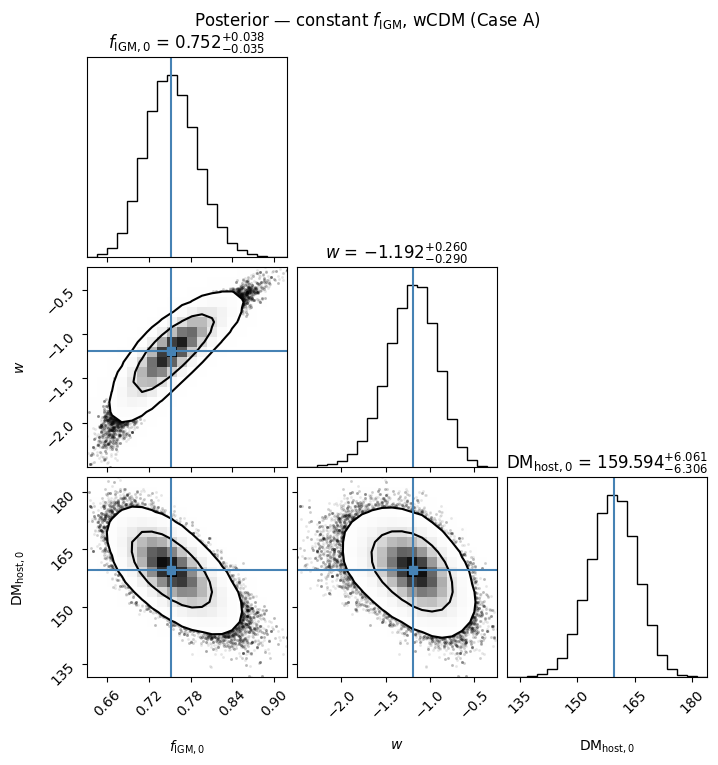

In [14]:
tau_const     = sampler_const.get_autocorr_time()
burn_const    = int(2 * np.max(tau_const))
samples_const = sampler_const.get_chain(discard=burn_const, flat=True)

f_IGM_0_mcmc = np.percentile(samples_const[:, 0], [16, 50, 84])
w_mcmc       = np.percentile(samples_const[:, 1], [16, 50, 84])
DM_host_mcmc = np.percentile(samples_const[:, 2], [16, 50, 84])

print("\n===== RESULTS (Constant f_IGM) =====\n")
print(f"f_IGM_0   = {f_IGM_0_mcmc[1]:.3f} +{f_IGM_0_mcmc[2]-f_IGM_0_mcmc[1]:.3f} -{f_IGM_0_mcmc[1]-f_IGM_0_mcmc[0]:.3f}")
print(f"w         = {w_mcmc[1]:.3f} +{w_mcmc[2]-w_mcmc[1]:.3f} -{w_mcmc[1]-w_mcmc[0]:.3f}")
print(f"DM_host_0 = {DM_host_mcmc[1]:.3f} +{DM_host_mcmc[2]-DM_host_mcmc[1]:.3f} -{DM_host_mcmc[1]-DM_host_mcmc[0]:.3f}")

fig = corner.corner(
    samples_const,
    labels=[r"$f_{\rm IGM,0}$", r"$w$", r"$\mathrm{DM}_{\rm host,0}$"],
    truths=[f_IGM_0_mcmc[1], w_mcmc[1], DM_host_mcmc[1]],
    show_titles=True, title_fmt=".3f",
    levels=(0.68, 0.95), smooth=1.0
)
plt.suptitle(r"Posterior — constant $f_{\rm IGM}$, wCDM (Case A)", y=1.01)
plt.show()

### Case B — Time-dependent $f_{\rm IGM}$

Free parameters: $f_{\rm IGM,0}$, $\alpha$, $w$, $\mathrm{DM}_{\rm host,0}$.

In [15]:
def log_prior_timedep(params):
    f_IGM_0, alpha, w, DM_host_0 = params
    if (0.0 <= f_IGM_0 <= 1.0 and 0.0 <= alpha <= 3.0
            and -2.5 <= w <= 1.0 and 0.0 <= DM_host_0 <= 300.0):
        return 0.0
    return -np.inf

def log_prob_timedep(params):
    lp = log_prior_timedep(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, f_IGM_timedep)

In [16]:
nDim_timedep     = 4
nwalkers_timedep = 32

initial_guess_timedep = np.array([0.7, 1.0, -1.0, 150.0])
pos_timedep = initial_guess_timedep + np.array([0.05, 0.1, 0.1, 30.0]) * np.random.randn(nwalkers_timedep, nDim_timedep)
pos_timedep[:, 0] = np.clip(pos_timedep[:, 0], 0.01, 0.99)
pos_timedep[:, 1] = np.clip(pos_timedep[:, 1], 0.0,  3.0)
pos_timedep[:, 2] = np.clip(pos_timedep[:, 2], -2.49, 0.99)
pos_timedep[:, 3] = np.clip(pos_timedep[:, 3], 10.0, 299.0)

n_cores = multiprocessing.cpu_count()
with multiprocessing.Pool(processes=n_cores) as pool:
    sampler_timedep = emcee.EnsembleSampler(nwalkers_timedep, nDim_timedep, log_prob_timedep, pool=pool)
    print(f"Running MCMC for time-dependent f_IGM with {n_cores} cores...")
    sampler_timedep.run_mcmc(pos_timedep, 5000, progress=True)
    print("Done.")

Running MCMC for time-dependent f_IGM with 2 cores...


100%|██████████| 5000/5000 [10:20<00:00,  8.06it/s]

Done.



===== RESULTS (Time-dependent f_IGM) =====

f_IGM_0   = 0.503 +0.068 -0.066
alpha     = 1.319 +0.352 -0.328
w         = -0.831 +0.292 -0.323
DM_host_0 = 188.784 +9.287 -9.215


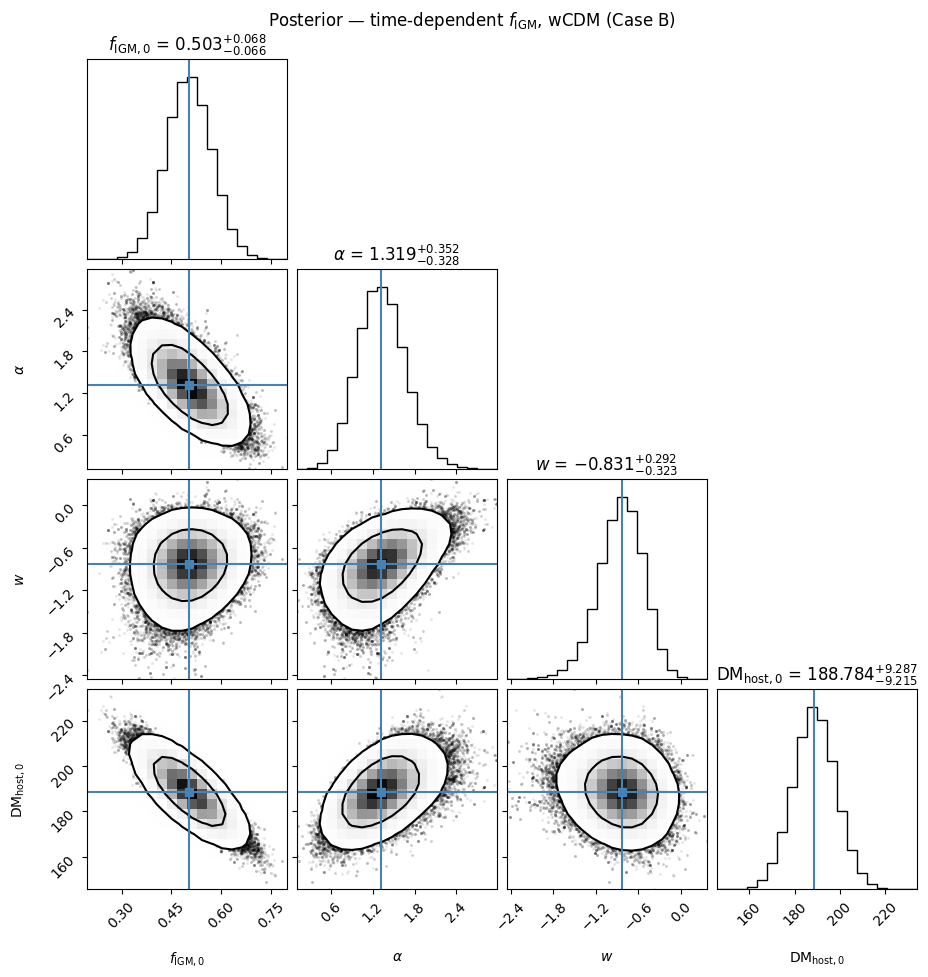

In [17]:
tau_timedep     = sampler_timedep.get_autocorr_time()
burn_timedep    = int(2 * np.max(tau_timedep))
samples_timedep = sampler_timedep.get_chain(discard=burn_timedep, flat=True)

f_IGM_0_td = np.percentile(samples_timedep[:, 0], [16, 50, 84])
alpha_td   = np.percentile(samples_timedep[:, 1], [16, 50, 84])
w_td       = np.percentile(samples_timedep[:, 2], [16, 50, 84])
DM_host_td = np.percentile(samples_timedep[:, 3], [16, 50, 84])

print("\n===== RESULTS (Time-dependent f_IGM) =====\n")
print(f"f_IGM_0   = {f_IGM_0_td[1]:.3f} +{f_IGM_0_td[2]-f_IGM_0_td[1]:.3f} -{f_IGM_0_td[1]-f_IGM_0_td[0]:.3f}")
print(f"alpha     = {alpha_td[1]:.3f} +{alpha_td[2]-alpha_td[1]:.3f} -{alpha_td[1]-alpha_td[0]:.3f}")
print(f"w         = {w_td[1]:.3f} +{w_td[2]-w_td[1]:.3f} -{w_td[1]-w_td[0]:.3f}")
print(f"DM_host_0 = {DM_host_td[1]:.3f} +{DM_host_td[2]-DM_host_td[1]:.3f} -{DM_host_td[1]-DM_host_td[0]:.3f}")

fig = corner.corner(
    samples_timedep,
    labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$w$", r"$\mathrm{DM}_{\rm host,0}$"],
    truths=[f_IGM_0_td[1], alpha_td[1], w_td[1], DM_host_td[1]],
    show_titles=True, title_fmt=".3f",
    levels=(0.68, 0.95), smooth=1.0
)
plt.suptitle(r"Posterior — time-dependent $f_{\rm IGM}$, wCDM (Case B)", y=1.01)
plt.show()

## **4. MODEL COMPARISON**

Nested sampling computes the Bayesian evidence $\mathcal{Z} = P(D|M)$, which allows direct model comparison via:
$$
\Delta \ln \mathcal{Z} = \ln \mathcal{Z}_{\rm evolving} - \ln \mathcal{Z}_{\rm constant}.
$$

| $\Delta \ln \mathcal{Z}$ | Interpretation |
|---|---|
| $<1$ | inconclusive |
| $1-3$ | weak evidence |
| $3-5$ | moderate evidence |
| $>5$ | strong evidence |

In [18]:
!pip install dynesty -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.6 MB/s eta 0:00:00


### Case A — Constant $f_{\rm IGM}$

In [19]:
from dynesty import NestedSampler

def log_likelihood_const_dynesty(params):
    return log_likelihood(params, f_IGM_const)

def prior_transform_const(u):
    f_IGM_0   = u[0] * 1.0
    w         = u[1] * 3.5 - 2.5      # maps [0,1] → [-2.5, 1.0]
    DM_host_0 = u[2] * 300.0
    return [f_IGM_0, w, DM_host_0]

ndim_const = 3

sampler_dynesty_const = NestedSampler(
    log_likelihood_const_dynesty,
    prior_transform_const,
    ndim_const,
    nlive=1000
)
sampler_dynesty_const.run_nested(dlogz=0.01)

results_dynesty_const = sampler_dynesty_const.results
print("\n--- Dynesty Results (Constant f_IGM) ---")
results_dynesty_const.summary()

13330it [03:48, 58.24it/s, +1000 | bound: 22 | nc: 1 | ncall: 58315 | eff(%): 25.002 | loglstar:   -inf < -553.631 <    inf | logz: -562.343 +/-  0.085 | dlogz:  0.000 >  0.010]


--- Dynesty Results (Constant f_IGM) ---
Summary
nlive: 1000
niter: 13330
ncall: 57315
eff(%): 25.002
logz: -562.343 +/-  0.088


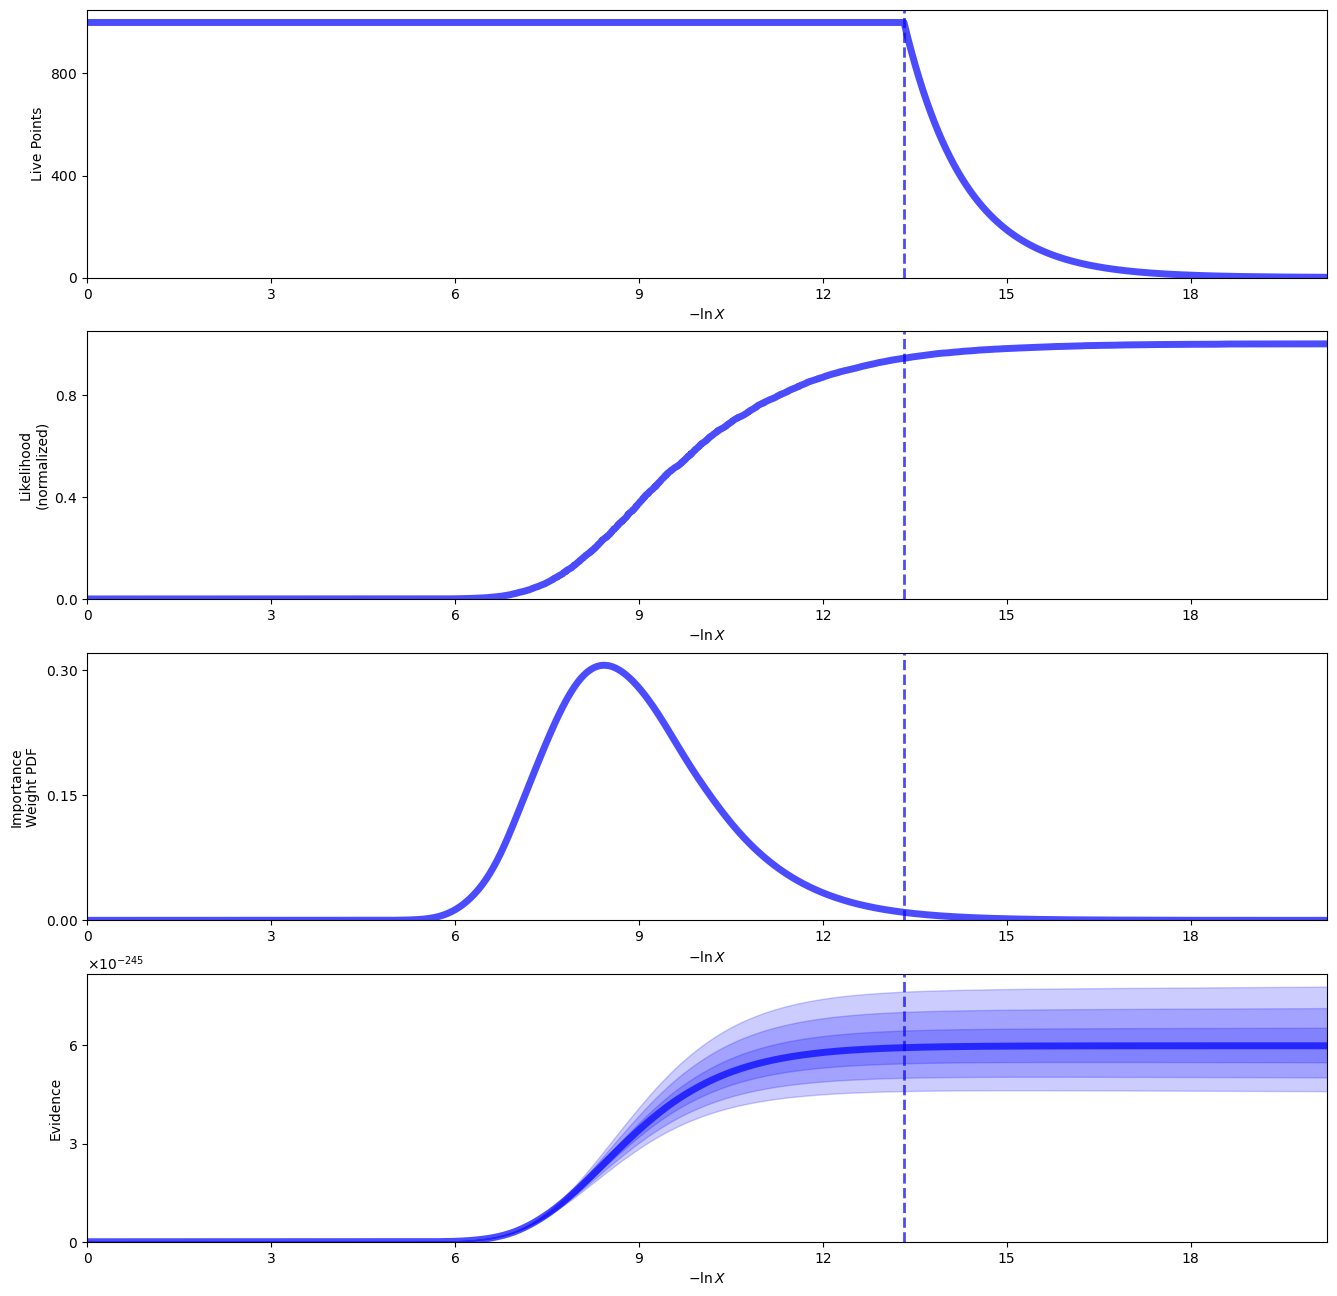

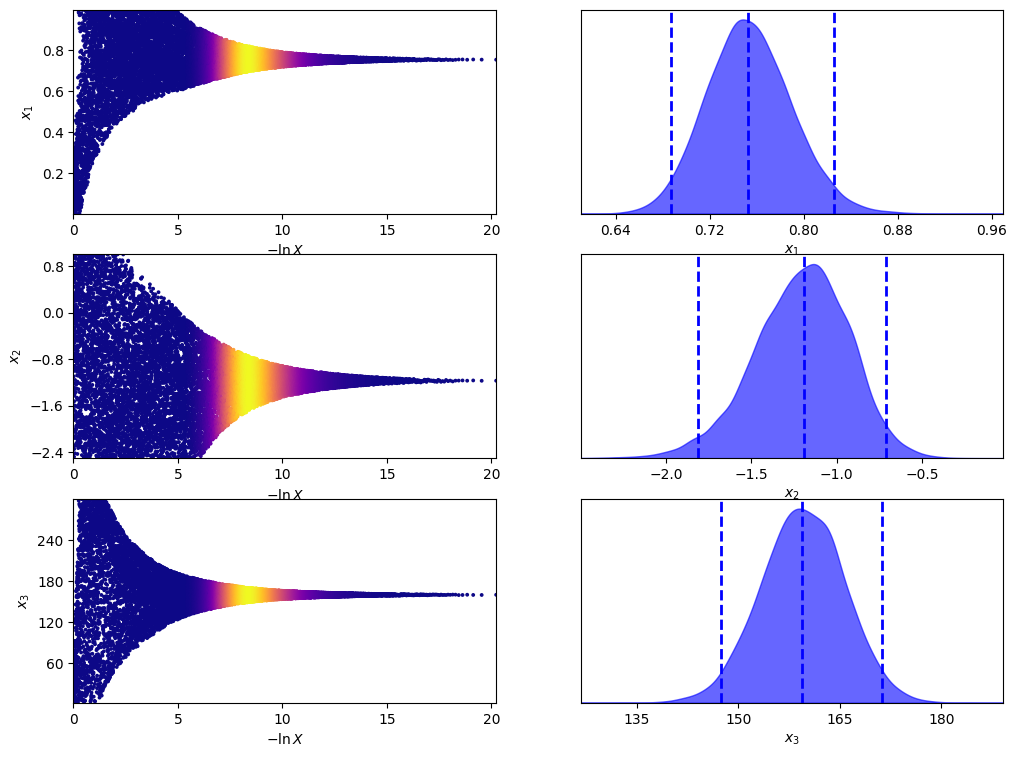

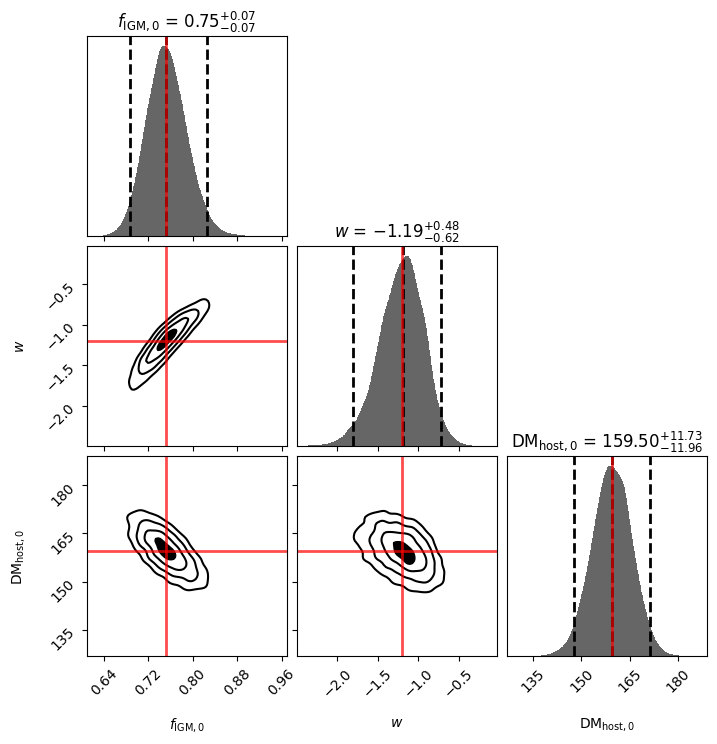

In [20]:
from dynesty import plotting as dyplot

rfig_const, raxes_const = dyplot.runplot(results_dynesty_const)
tfig_const, taxes_const = dyplot.traceplot(results_dynesty_const)

samples_const_dynesty = results_dynesty_const.samples_equal()
f_med_const           = np.percentile(samples_const_dynesty[:, 0], 50)
w_med_const           = np.percentile(samples_const_dynesty[:, 1], 50)
D_med_const           = np.percentile(samples_const_dynesty[:, 2], 50)

dffig_const, dfaxes_const = dyplot.cornerplot(
    results_dynesty_const,
    labels=[r"$f_{\rm IGM,0}$", r"$w$", r"$\mathrm{DM}_{\rm host,0}$"],
    truths=[f_med_const, w_med_const, D_med_const],
    show_titles=True
)

### Case B — Time-dependent $f_{\rm IGM}$

In [21]:
def log_likelihood_timedep_dynesty(params):
    return log_likelihood(params, f_IGM_timedep)

def prior_transform_timedep(u):
    f_IGM_0   = u[0] * 1.0
    alpha     = u[1] * 3.0
    w         = u[2] * 3.5 - 2.5      # maps [0,1] → [-2.5, 1.0]
    DM_host_0 = u[3] * 300.0
    return [f_IGM_0, alpha, w, DM_host_0]

nDim_timedep_dynesty = 4

sampler_dynesty_timedep = NestedSampler(
    log_likelihood_timedep_dynesty,
    prior_transform_timedep,
    nDim_timedep_dynesty,
    nlive=1000
)
sampler_dynesty_timedep.run_nested(dlogz=0.01)

results_dynesty_timedep = sampler_dynesty_timedep.results
print("\n--- Dynesty Results (Time-dependent f_IGM) ---")
results_dynesty_timedep.summary()

14467it [04:39, 51.80it/s, +1000 | bound: 35 | nc: 1 | ncall: 72233 | eff(%): 21.713 | loglstar:   -inf < -543.913 <    inf | logz: -553.763 +/-  0.089 | dlogz:  0.000 >  0.010]


--- Dynesty Results (Time-dependent f_IGM) ---
Summary
nlive: 1000
niter: 14467
ncall: 71233
eff(%): 21.713
logz: -553.763 +/-  0.092


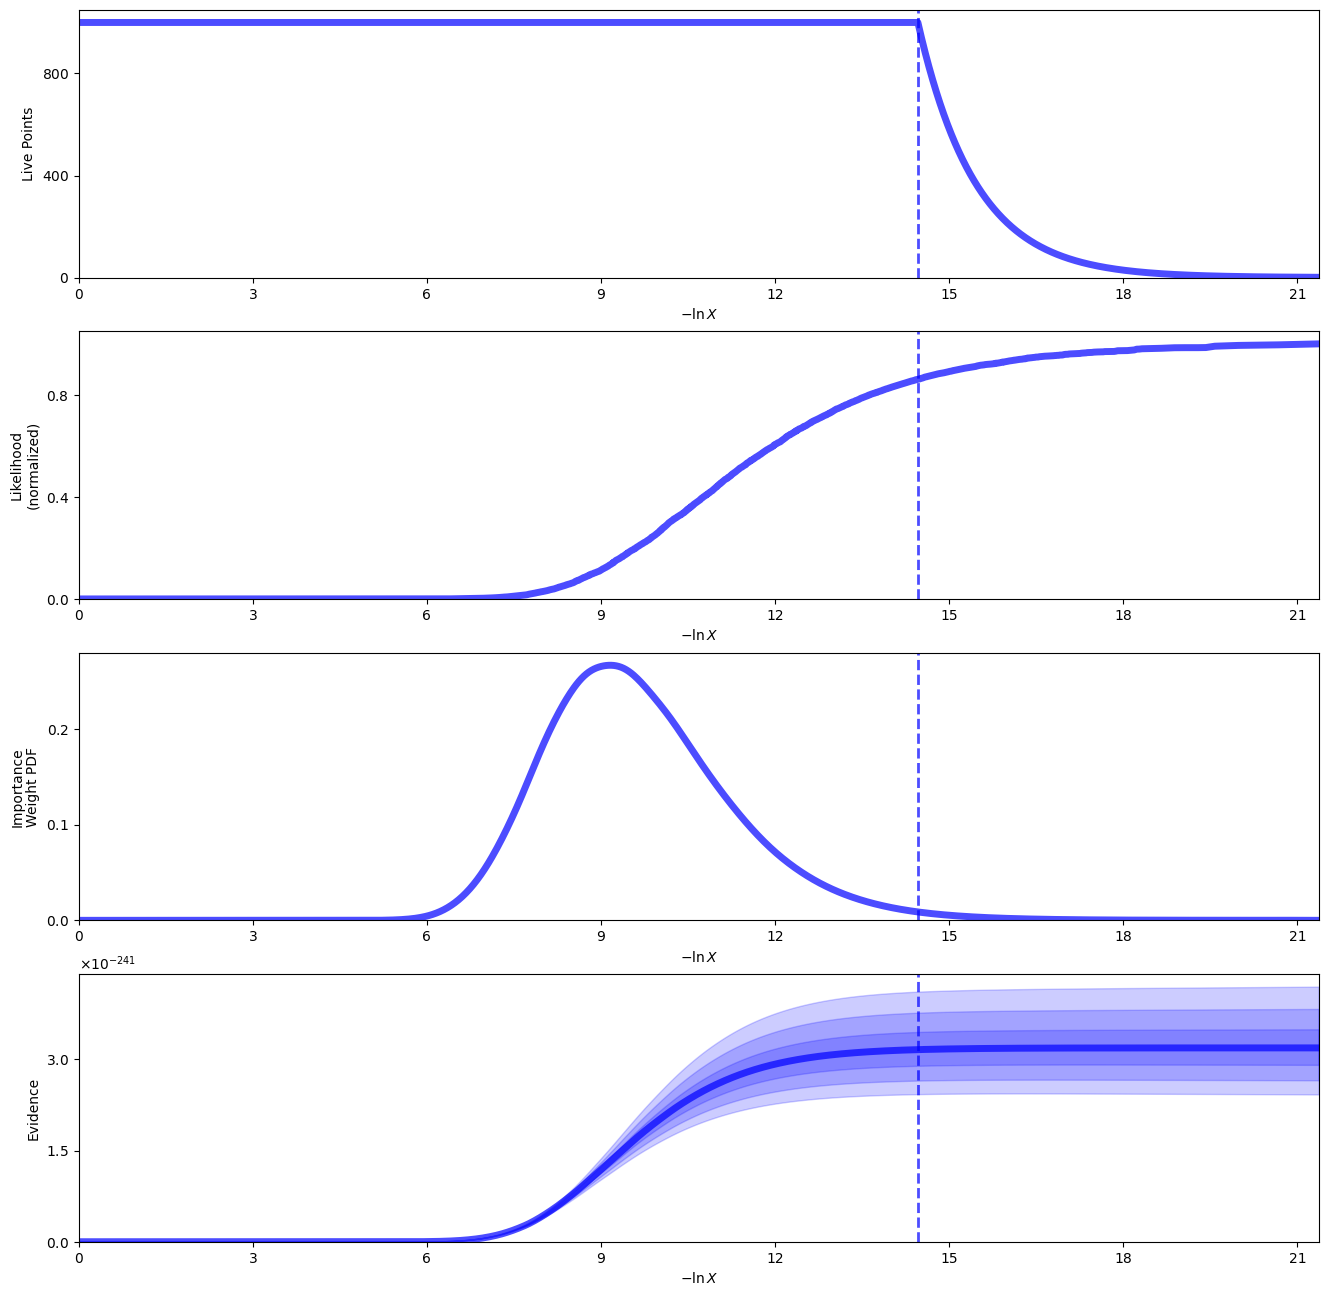

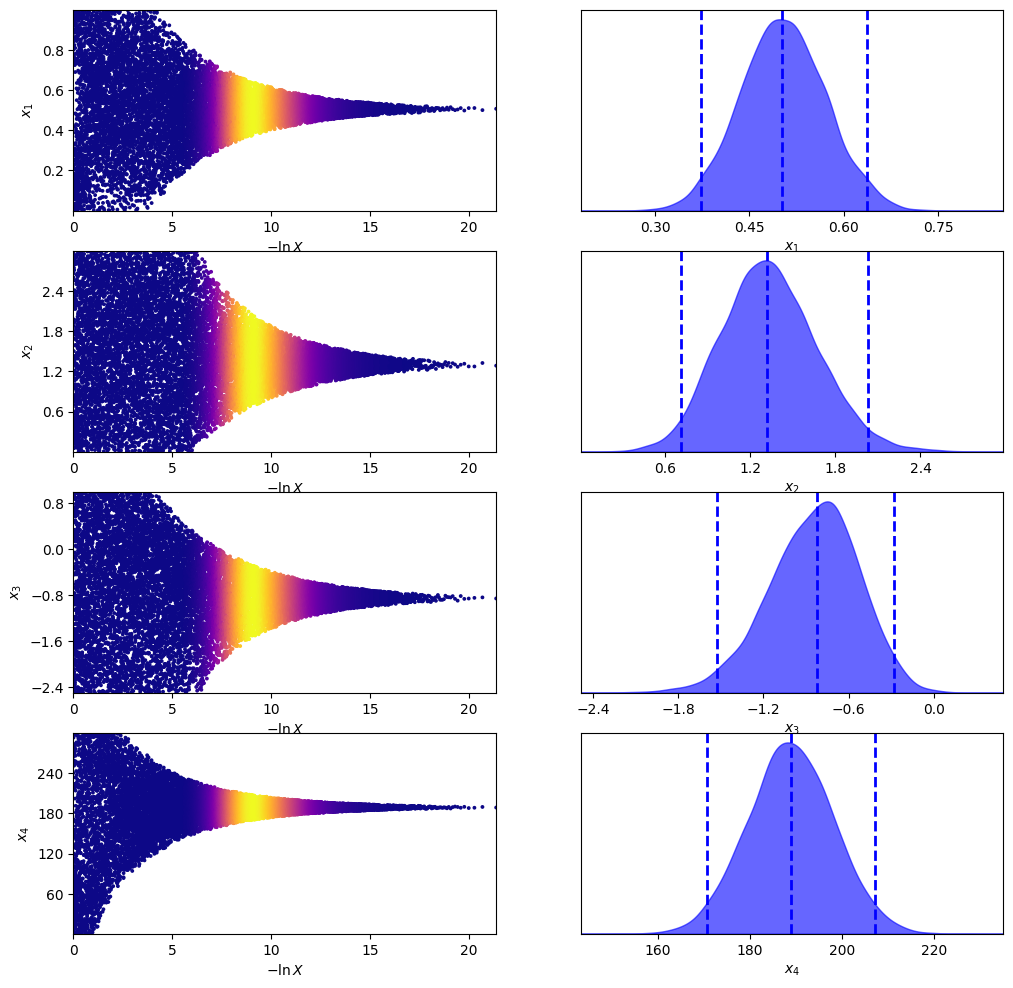

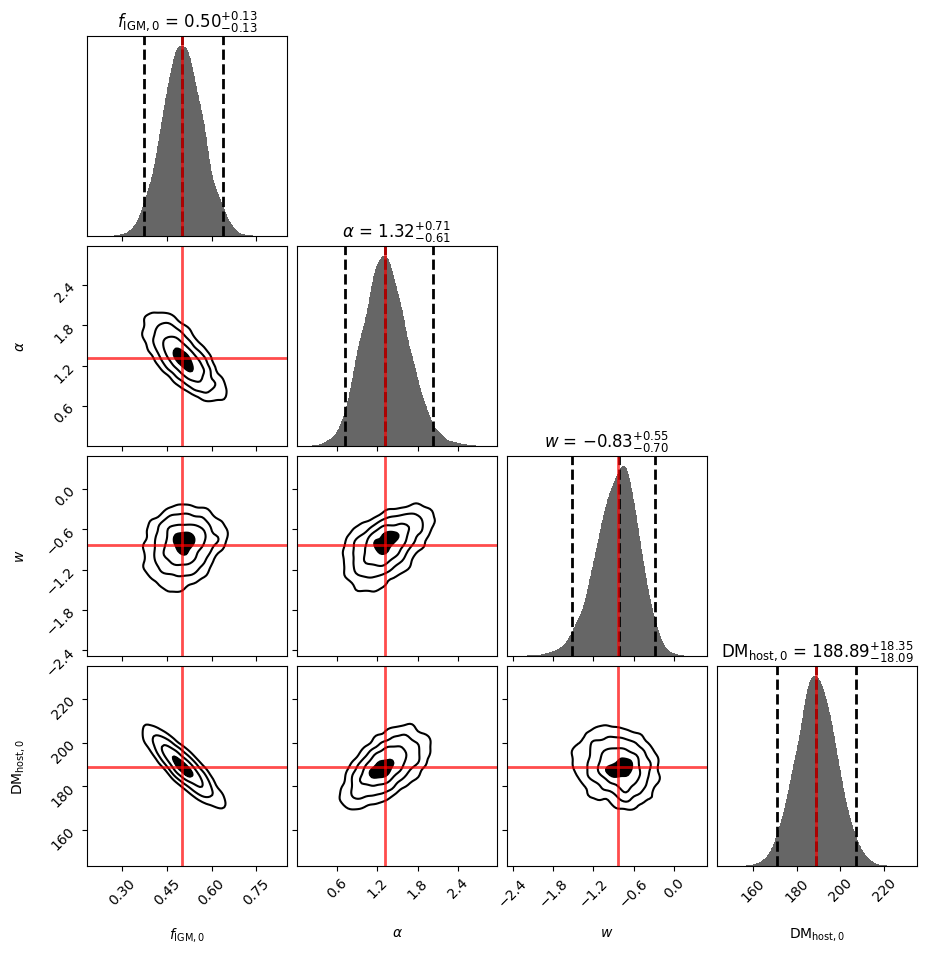

In [22]:
rfig_timedep, raxes_timedep = dyplot.runplot(results_dynesty_timedep)
tfig_timedep, taxes_timedep = dyplot.traceplot(results_dynesty_timedep)

samples_timedep_dynesty   = results_dynesty_timedep.samples_equal()
f_med_timedep             = np.percentile(samples_timedep_dynesty[:, 0], 50)
alpha_med_timedep         = np.percentile(samples_timedep_dynesty[:, 1], 50)
w_med_timedep             = np.percentile(samples_timedep_dynesty[:, 2], 50)
D_med_timedep             = np.percentile(samples_timedep_dynesty[:, 3], 50)

dffig_timedep, dfaxes_timedep = dyplot.cornerplot(
    results_dynesty_timedep,
    labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$w$", r"$\mathrm{DM}_{\rm host,0}$"],
    truths=[f_med_timedep, alpha_med_timedep, w_med_timedep, D_med_timedep],
    show_titles=True
)

### Model Comparison Results

We compare the two models based on their Bayesian evidence values ($\mathcal{Z}$) calculated using `dynesty`. The difference in log-evidence $\Delta\, \ln\, \mathcal{Z}$ determines model preference via the Jeffreys scale.

In [23]:
logz_const    = results_dynesty_const.logz[-1]
logzerr_const = results_dynesty_const.logzerr[-1]

logz_timedep    = results_dynesty_timedep.logz[-1]
logzerr_timedep = results_dynesty_timedep.logzerr[-1]

Delta_ln_Z     = logz_timedep - logz_const
Delta_ln_Z_err = np.sqrt(logzerr_const**2 + logzerr_timedep**2)

print(f"\n--- Model Comparison Results ---")
print(f"ln(Z_constant)       = {logz_const:.3f} +/- {logzerr_const:.3f}")
print(f"ln(Z_time-dependent) = {logz_timedep:.3f} +/- {logzerr_timedep:.3f}")
print(f"Delta ln(Z)          = {Delta_ln_Z:.3f} +/- {Delta_ln_Z_err:.3f}\n")

if Delta_ln_Z < 1:
    interpretation = "inconclusive"
elif 1 <= Delta_ln_Z < 3:
    interpretation = "weak evidence for time-dependent model"
elif 3 <= Delta_ln_Z < 5:
    interpretation = "moderate evidence for time-dependent model"
else:
    interpretation = "strong evidence for time-dependent model"

print(f"Interpretation (Jeffreys' Scale): {interpretation}")


--- Model Comparison Results ---
ln(Z_constant)       = -562.343 +/- 0.088
ln(Z_time-dependent) = -553.763 +/- 0.092
Delta ln(Z)          = 8.580 +/- 0.127

Interpretation (Jeffreys' Scale): strong evidence for time-dependent model


## **5. SAVING**

In [24]:
# ---------------------------------------------------------------------------
# 5.1  MOUNT GOOGLE DRIVE + SETUP
# ---------------------------------------------------------------------------
import os, json
import h5py
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR  = "/content/drive/MyDrive/frb_cosmology_thesis"
CHAINS_DIR   = os.path.join(PROJECT_DIR, "chains")
EVIDENCE_DIR = os.path.join(PROJECT_DIR, "evidence")

os.makedirs(CHAINS_DIR,   exist_ok=True)
os.makedirs(EVIDENCE_DIR, exist_ok=True)

print("Project  →", PROJECT_DIR)
print("Chains   →", CHAINS_DIR)
print("Evidence →", EVIDENCE_DIR)

Mounted at /content/drive
Project  → /content/drive/MyDrive/frb_cosmology_thesis
Chains   → /content/drive/MyDrive/frb_cosmology_thesis/chains
Evidence → /content/drive/MyDrive/frb_cosmology_thesis/evidence


In [25]:
# ---------------------------------------------------------------------------
# 5.2  CASE A — constant f_IGM
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "wcdm_caseA.h5"), "w") as f:
    f.create_dataset("chain", data=samples_const)
    f.attrs["param_names"]  = ["f_IGM_0", "w", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"w", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_const)
    f.attrs["logzerr"]      = float(logzerr_const)
    f.attrs["note"]         = "burned-in and thinned emcee chain, wCDM Case A"

print("Saved: wcdm_caseA.h5")

Saved: wcdm_caseA.h5


In [26]:
# ---------------------------------------------------------------------------
# 5.3  CASE B — time-dependent f_IGM
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "wcdm_caseB.h5"), "w") as f:
    f.create_dataset("chain", data=samples_timedep)
    f.attrs["param_names"]  = ["f_IGM_0", "alpha", "w", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"\alpha", r"w", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_timedep)
    f.attrs["logzerr"]      = float(logzerr_timedep)
    f.attrs["note"]         = "burned-in and thinned emcee chain, wCDM Case B"

print("Saved: wcdm_caseB.h5")

Saved: wcdm_caseB.h5


In [27]:
# ---------------------------------------------------------------------------
# 5.4  BAYES EVIDENCE
# ---------------------------------------------------------------------------
entry = {
    "wcdm": {
        "case_A": {"logz": float(logz_const),   "logzerr": float(logzerr_const)},
        "case_B": {"logz": float(logz_timedep), "logzerr": float(logzerr_timedep)},
        "delta_lnZ_BvsA":     float(Delta_ln_Z),
        "delta_lnZ_BvsA_err": float(Delta_ln_Z_err),
    }
}

bayes_path = os.path.join(EVIDENCE_DIR, "bayes_evidence.json")
if os.path.exists(bayes_path):
    with open(bayes_path) as jf:
        existing = json.load(jf)
    existing.update(entry)
    entry = existing

with open(bayes_path, "w") as jf:
    json.dump(entry, jf, indent=2)

print("Saved: evidence/bayes_evidence.json")
print(json.dumps(entry, indent=2))

Saved: evidence/bayes_evidence.json
{
  "model_independent": {
    "case_A": {
      "logz": -560.5029264972775,
      "logzerr": 0.1978881268911515
    },
    "case_B": {
      "logz": -553.6351197594189,
      "logzerr": 0.22704803343448685
    },
    "delta_lnZ_BvsA": 6.8678067378585865,
    "delta_lnZ_BvsA_err": 0.30118187238105204
  },
  "lcdm": {
    "case_A": {
      "logz": -560.908909858381,
      "logzerr": 0.08017501071658768
    },
    "case_B": {
      "logz": -552.5211589836642,
      "logzerr": 0.08656340275996759
    },
    "delta_lnZ_BvsA": 8.387750874716744,
    "delta_lnZ_BvsA_err": 0.1179883682436083
  },
  "wcdm": {
    "case_A": {
      "logz": -562.3433344984181,
      "logzerr": 0.08789547666145543
    },
    "case_B": {
      "logz": -553.7632904370583,
      "logzerr": 0.09151753090531868
    },
    "delta_lnZ_BvsA": 8.580044061359786,
    "delta_lnZ_BvsA_err": 0.12689000465186537
  },
  "cpl": {
    "case_A": {
      "logz": -558.779049452327,
      "logzerr"